<h1 span style="color:#1E90FF; font-weight:bold;">Segundo algoritmo de detección de rostros</span></h1>

<h3 span style="color:orange; font-weight:bold;">1. Objetivo y funcionamiento.</span></h3>

Como explicamos anteriormente, esta aproximación es muy distinta a la anterior. Por simplicidad, en esta versión si el parámetro `apply_blur=True`, se distorsionarán todas las caras reconocidas (añadir otro parámetro para que también realizase selección como el anterior algoritmo sería trivial). Esto lo haremos con el objetivo de poder aplicarlo a vídeos y el tiempo real de nuestra propia webcam.

<h3 span style="color:orange; font-weight:bold;">2. Estructura del código.</span></h3>

- En primer lugar, para preprocesar la imagen inicial, aplicamos una corrección gamma para normalizar imágenes muy oscuras o muy claras, seguida de un suavizado gaussiano que reduce el ruido antes de cualquier segmentación de color.

- Convertimos la imagen a los espacios de color `YCrCb y HSV`, que son más robustos frente a cambios de iluminación, y generamos dos máscaras binarias basadas en rangos de color de piel específicos para cada espacio. Ambas máscaras se combinan mediante una intersección lógica, de modo que un píxel solo se considera piel si cumple simultáneamente las condiciones en ambos espacios.

- A continuación, refinamos la máscara aplicando operaciones morfológicas de cierre y apertura con un `kernel elíptico`, lo que permite rellenar huecos internos y eliminar ruido externo, obteniendo regiones de piel más compactas y limpias.

- Utilizamos la transformada de distancia para separar regiones de piel que estén pegadas entre sí (por ejemplo, rostros cercanos), extrayendo los núcleos de cada objeto y facilitando una correcta detección individual de cada cara.

- Extraemos los contornos de las regiones resultantes y evaluamos cada candidato mediante un sistema de `puntuación geométrica` que tiene en cuenta el área relativa, la relación de aspecto, la solidez del contorno y su posición en la imagen.

- Por último, generamos los bounding boxes finales aplicando un padding del 10 % para asegurar que la cara queda completamente cubierta y, si `apply_blur = True`, aplicamos un desenfoque gaussiano con bordes suavizados por estética.

In [41]:
pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
class ProFaceDetector:
    def __init__(self):
        """
        Define los rangos de color (YCrCb y HSV) ajustados para detectar piel.
        """
        self.cr_min, self.cr_max = 135, 180
        self.cb_min, self.cb_max = 85, 135
        self.h_min, self.h_max = 0, 25
        self.s_min = 20
        self.v_min = 60

    def adjust_gamma(self, image, gamma=1.3):
        """
        Aplica corrección gamma para normalizar imágenes muy oscuras o claras.
        """
        inv = 1.0 / gamma
        table = np.array([((i / 255.0) ** inv) * 255 for i in range(256)]).astype("uint8")
        # LUT mapea todos los valores de píxel usando una tabla de 256 valores de forma eficiente. 
        # También podría hacerse a mano pero es más lento. Evita fallos por iluminación.
        return cv2.LUT(image, table)

    def get_refined_mask(self, img):
        """
        Genera una máscara binaria combinando espacios de color y limpieza morfológica.
        """
        # Preprocesamiento: Gamma y desenfoque para reducir ruido
        img = self.adjust_gamma(img)
        blur = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Conversión a espacios de color robustos a la iluminación
        ycrcb = cv2.cvtColor(blur, cv2.COLOR_BGR2YCrCb)
        hsv = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
        
        # Creación de máscaras por umbrales
        mask_crcb = cv2.inRange(ycrcb, (0, self.cr_min, self.cb_min), (255, self.cr_max, self.cb_max))
        mask_hsv = cv2.inRange(hsv, (self.h_min, self.s_min, self.v_min), (self.h_max, 255, 255))
        
        # Intersección: el píxel debe cumplir ambas condiciones (reduce falsos positivos)
        combined = cv2.bitwise_and(mask_crcb, mask_hsv)
        
        # Operaciones morfológicas para cerrar huecos y limpiar ruido externo
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=3)
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)
        return combined

    def separate_touching_faces(self, mask):
        """
        Usa Transformada de Distancia para separar rostros que aparecen pegados en la máscara.
        """
        dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
        cv2.normalize(dist, dist, 0, 1, cv2.NORM_MINMAX)
        m = dist.max()
        
        # Umbral del 20% del pico máximo para separar núcleos de objetos
        if m > 0:
            _, fg = cv2.threshold(dist, 0.20 * m, 255, 0)
        else:
            fg = mask.copy()
        return np.uint8(fg)
    
    def process(self, img_or_path, visualize=True, apply_blur=False):
        """
        Función principal. Detecta rostros y, si apply_blur=True, los difumina automáticamente.
        """
        if isinstance(img_or_path, str):
            img = cv2.imread(img_or_path)
            if img is None:
                print("error img")
                return None, []
        else:
            img = img_or_path.copy()

        out = img.copy()
        h_img, w_img = img.shape[:2]
        total = h_img * w_img

        # 1. Obtención y separación de la máscara de piel
        raw_mask = self.get_refined_mask(img)
        mask = self.separate_touching_faces(raw_mask)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        cands = []
        if visualize: print("IDs:")

        for i, c in enumerate(contours, 1):
            area = cv2.contourArea(c)
            # Filtro de área: descarta ruido muy pequeño o regiones enormes (cuerpos enteros)
            if area < (0.0005 * total) or area > (0.15 * total):
                continue

            x, y, w, h = cv2.boundingRect(c)
            
            # Puntuación geométrica para validar candidatos
            ar = w / float(h)
            score = 0

            # Puntos por relación de aspecto (forma de cara vs forma alargada)
            if 0.55 < ar < 0.95:
                score += 10
            elif 0.35 < ar < 1.2:
                score += 5
            else:
                score -= 10 # Penaliza formas muy anchas o muy planas

            if ar < 0.35:
                score -= 15 # Penaliza formas demasiado delgadas

            # Puntos por solidez (como de lleno está el contorno)
            hull = cv2.convexHull(c)
            ha = cv2.contourArea(hull)
            sol = area / ha if ha > 0 else 0
            if sol > 0.80:
                score += 5

            # Penalizamos si está pegado al borde inferior
            if y + h > h_img * 0.99:
                score -= 5

            # Si pasa el umbral de puntuación, es un candidato válido
            if score >= 5:
                # Padding del 20% para cubrir toda la cara
                pw = int(w * 0.2)
                ph = int(h * 0.2)
                x1 = max(0, x - pw)
                y1 = max(0, y - ph)
                x2 = min(w_img, x + w + pw)
                y2 = min(h_img, y + h + ph)
                
                box = (x1, y1, x2 - x1, y2 - y1)
                cands.append(box)
                
                # Dibujamos bounding boxes para visualización
                cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(out, str(len(cands)), (x1 + 5, y1 + 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                if visualize: print(len(cands), end=" ")
        
        if visualize: print()

        # Visualización de pasos intermedios
        if visualize:
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.subplot(1, 3, 2)
            plt.imshow(mask, cmap='gray')
            plt.axis('off')
            plt.subplot(1, 3, 3)
            plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()

        final_anon = img.copy()

        # Si apply_blur es True, difuminamos todos los candidatos encontrados automáticamente
        if apply_blur:
            for i, (x, y, w, h) in enumerate(cands, 1):
                roi = final_anon[y:y+h, x:x+w]
                k = (w // 3) | 1  # Kernel dinámico según tamaño de cara
                
                # Máscara elíptica para suavizar la transición del blur
                m_blur = np.zeros((h, w), dtype=np.float32)
                cv2.ellipse(m_blur, (w//2, h//2), (int(w*0.4), int(h*0.4)), 0, 0, 360, 1.0, -1)
                m_blur = cv2.GaussianBlur(m_blur, (k, k), 0)[..., None] 
                
                # Aplicar blur y mezclar con original usando la máscara
                blurred_roi = cv2.GaussianBlur(roi, (k, k), 30)
                final_anon[y:y+h, x:x+w] = (blurred_roi * m_blur + roi * (1 - m_blur)).astype(np.uint8)

            if visualize:
                plt.imshow(cv2.cvtColor(final_anon, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.show()
                
        return final_anon, cands

IDs:
1 


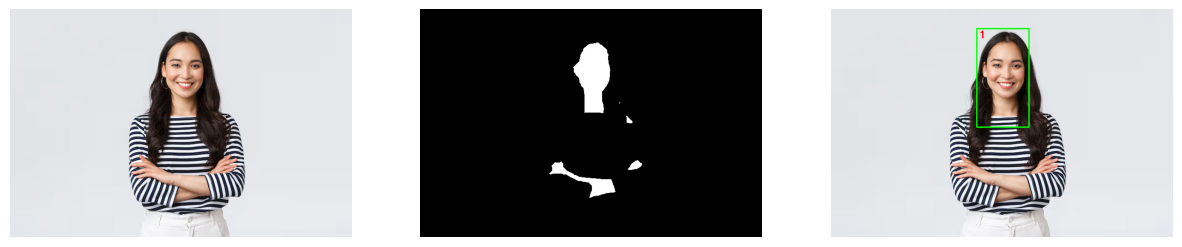

IDs:
1 2 3 4 5 6 


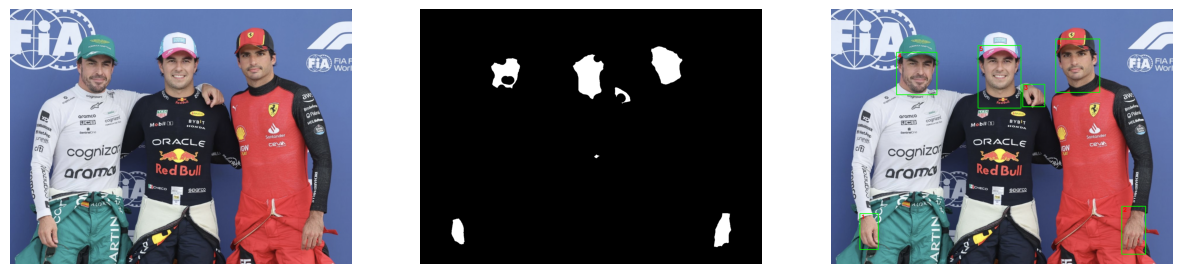

IDs:
1 2 3 4 5 6 7 8 


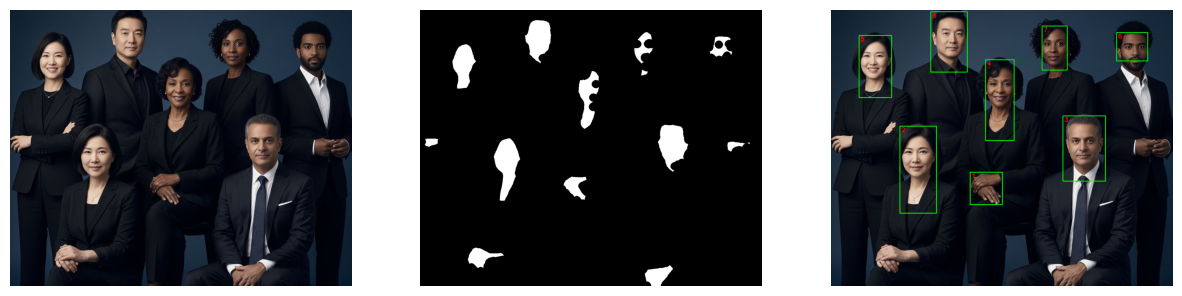

IDs:
1 


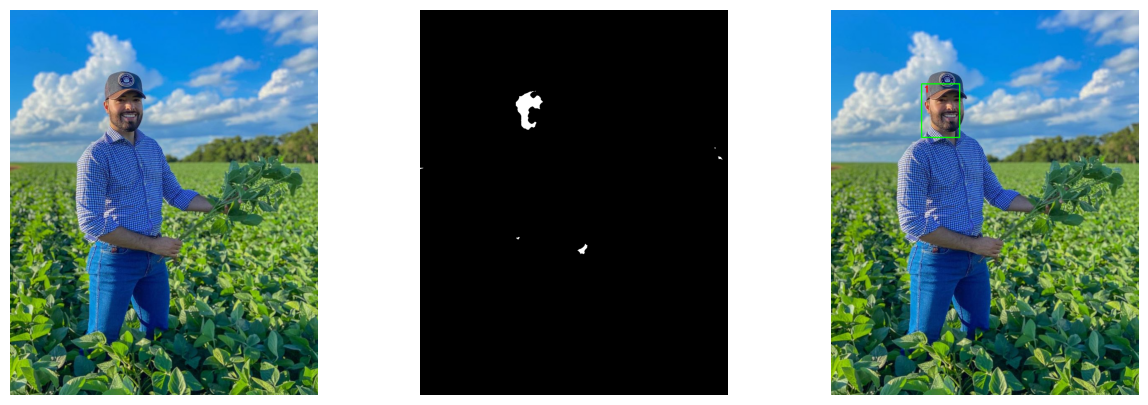

IDs:
1 2 3 4 5 


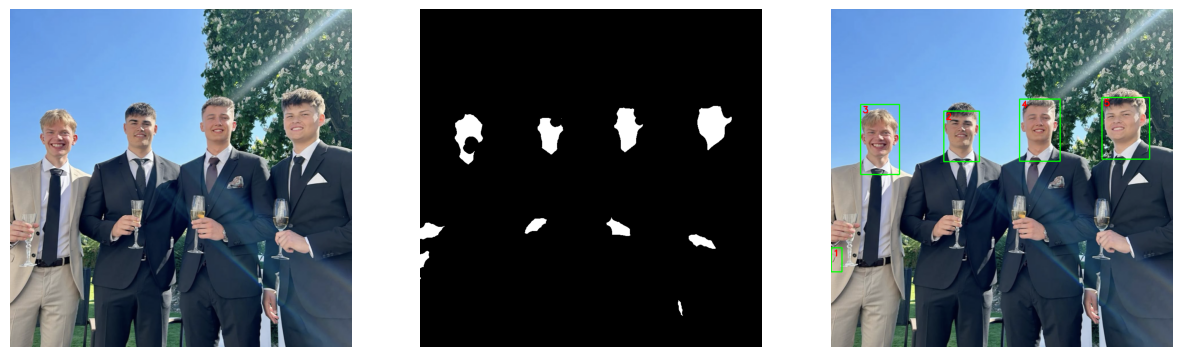

IDs:
1 2 3 4 5 6 7 8 


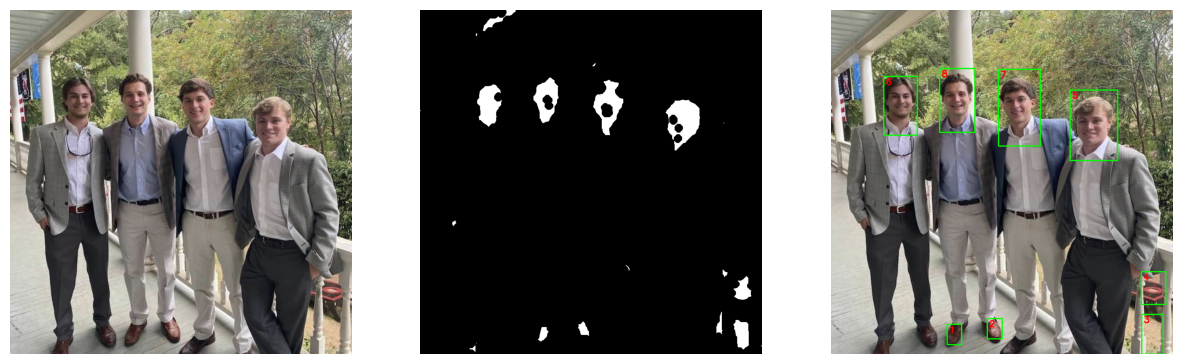

IDs:
1 2 3 4 5 6 


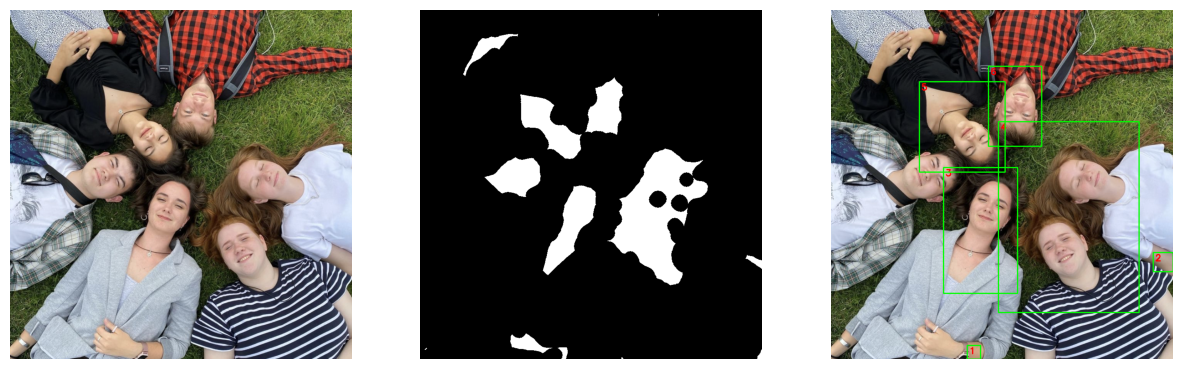

IDs:
1 2 3 4 5 6 7 8 9 


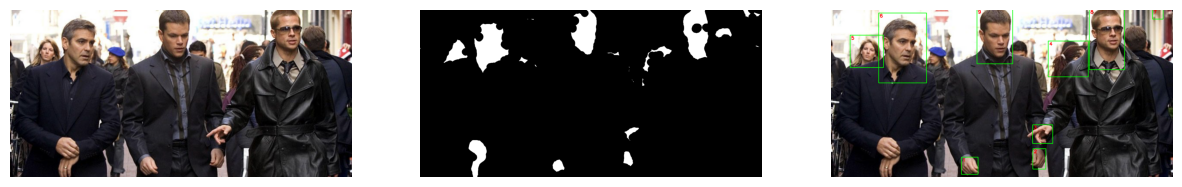

IDs:
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 


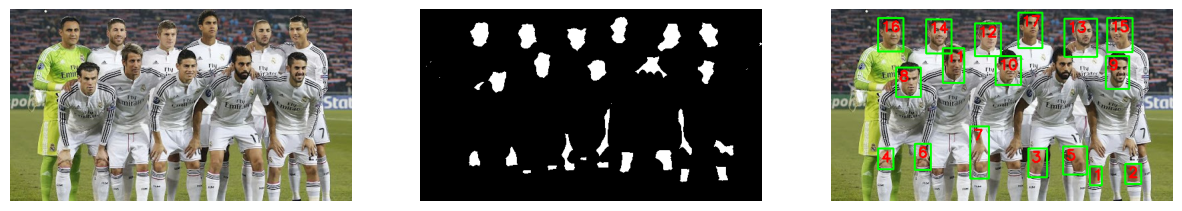

IDs:
1 2 3 4 5 6 


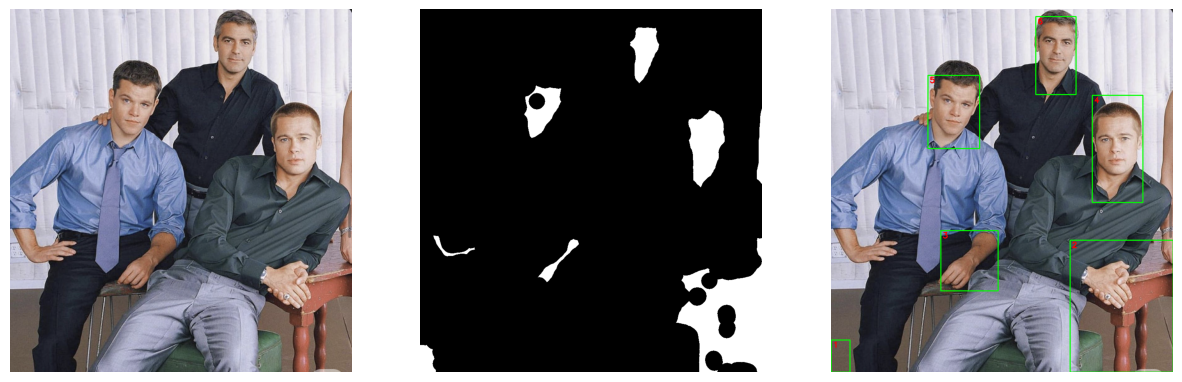

IDs:
1 2 


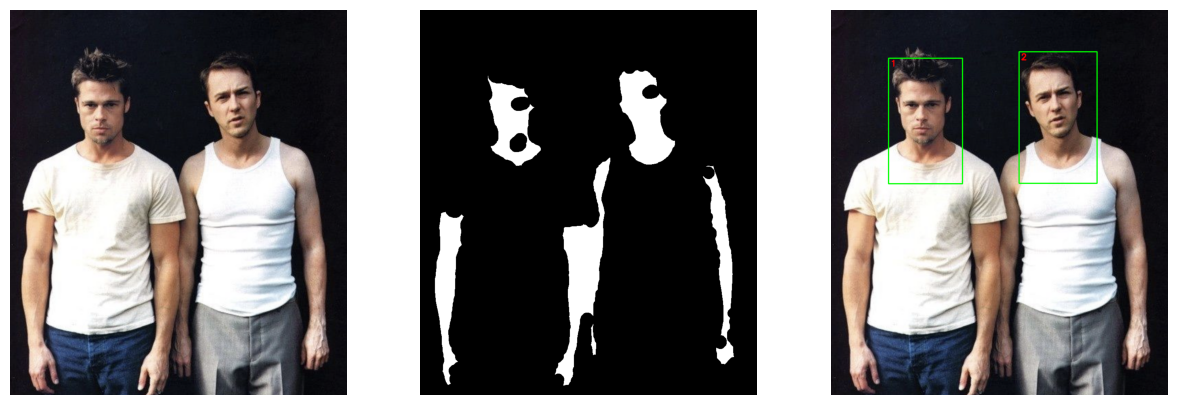

IDs:
1 2 


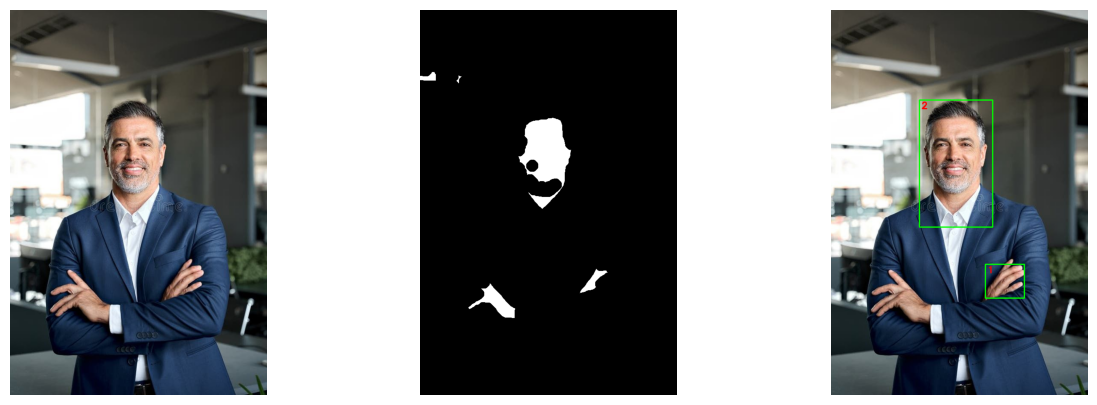

IDs:
1 2 3 4 5 6 


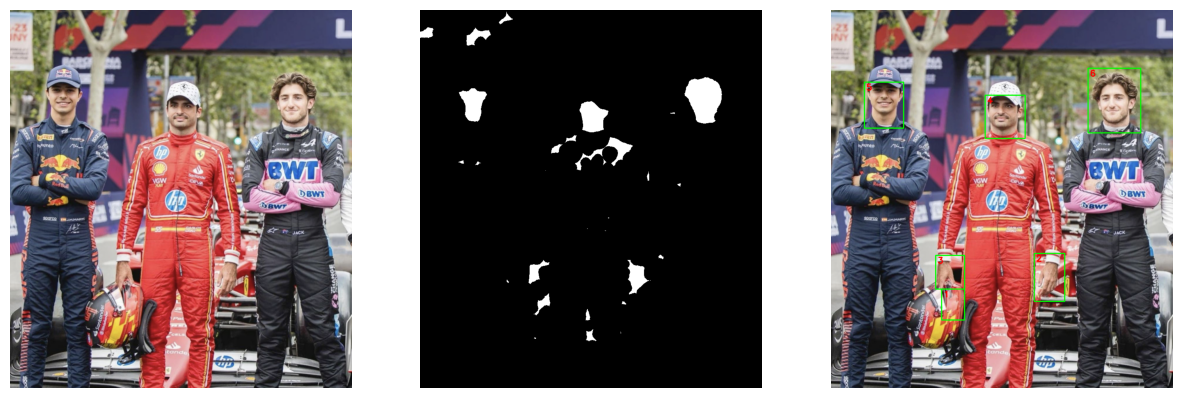

IDs:
1 2 


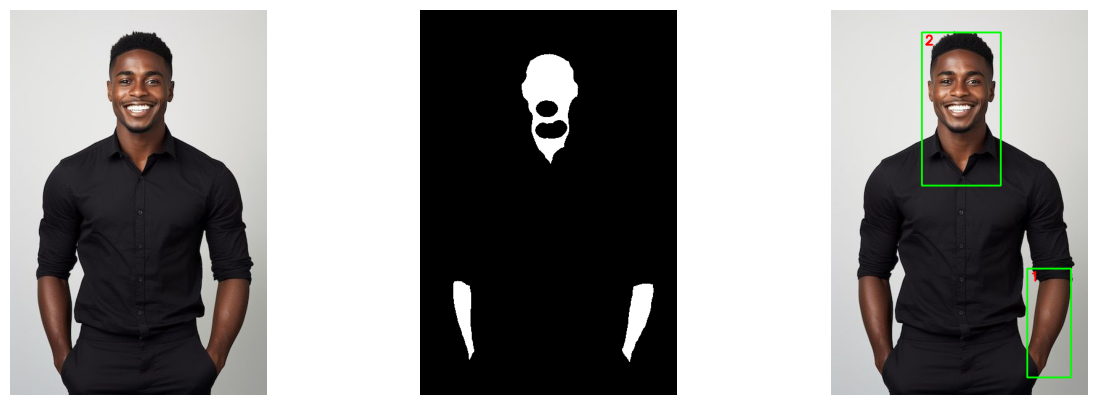

IDs:
1 2 3 4 5 


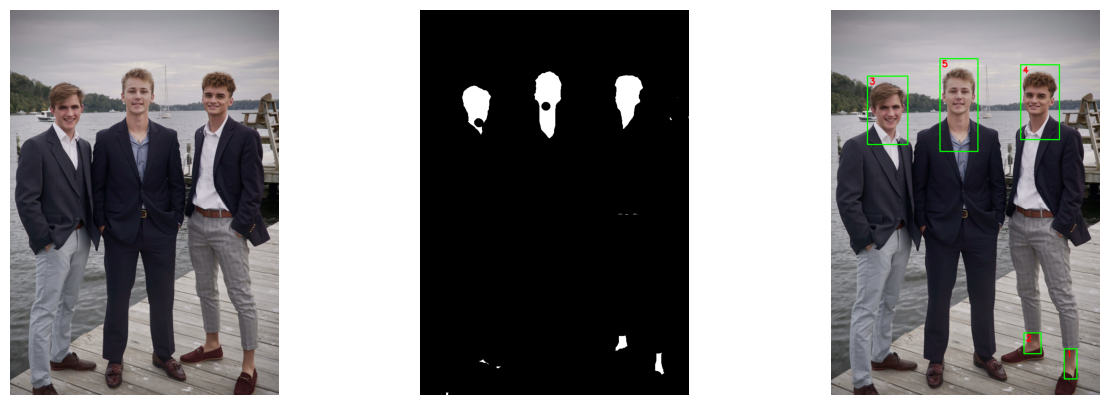

IDs:
1 2 3 4 5 6 7 8 


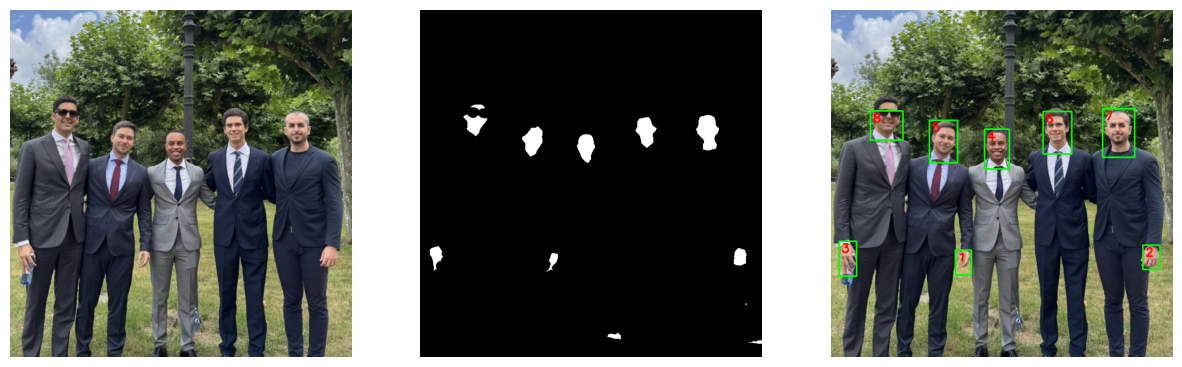

IDs:
1 2 3 4 5 6 7 


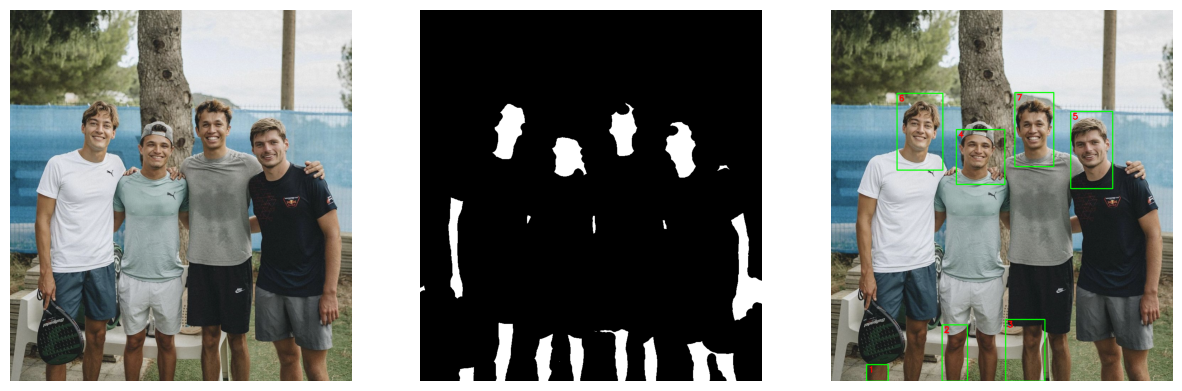

IDs:
1 2 3 4 5 6 7 


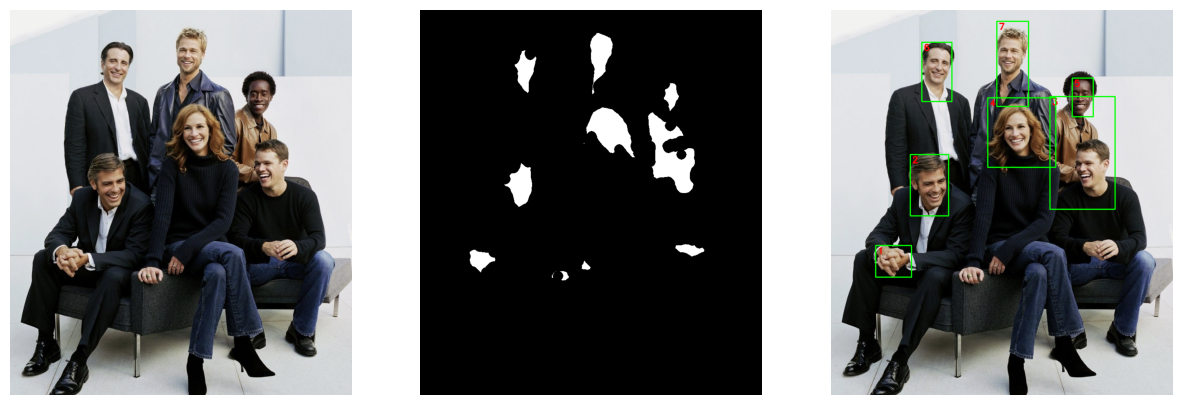

IDs:
1 2 3 4 5 


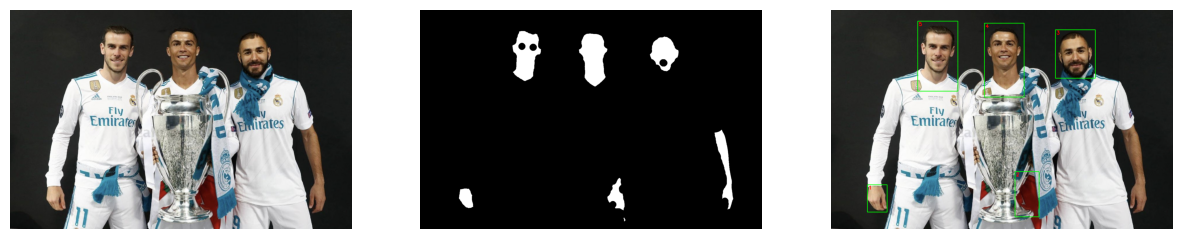

IDs:
1 2 3 4 5 6 7 


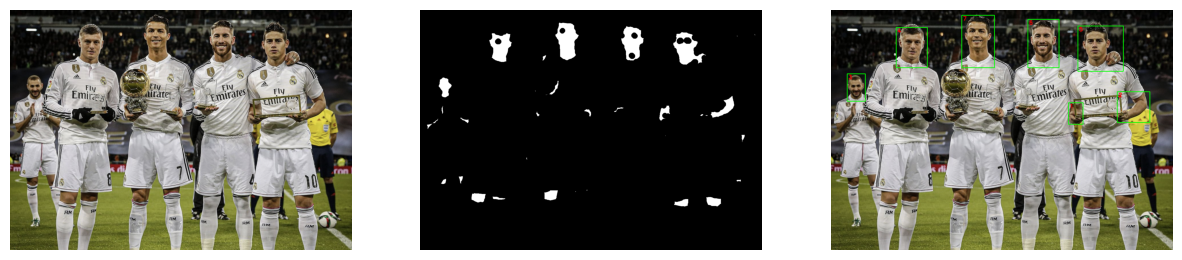

IDs:
1 2 3 


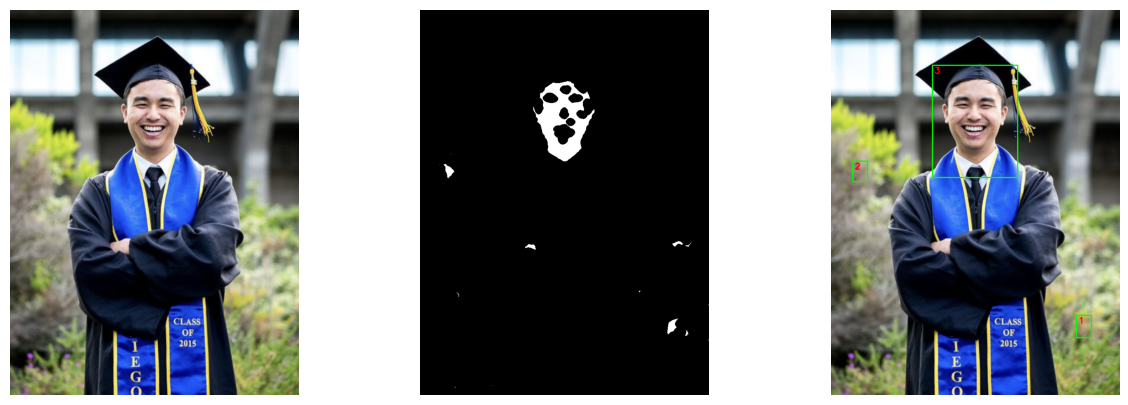

IDs:
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 


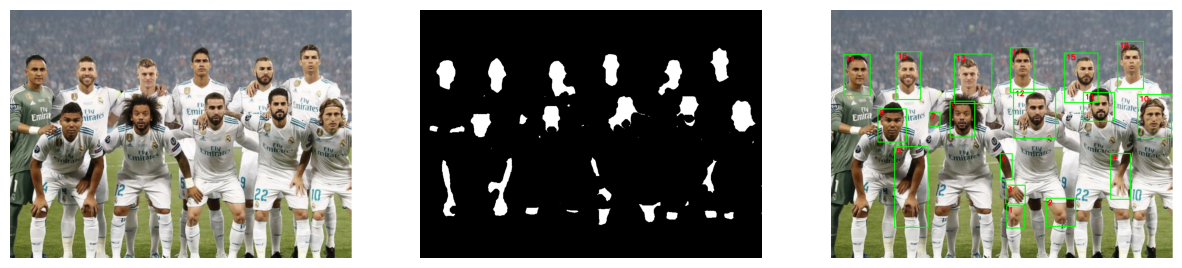

IDs:
1 2 3 


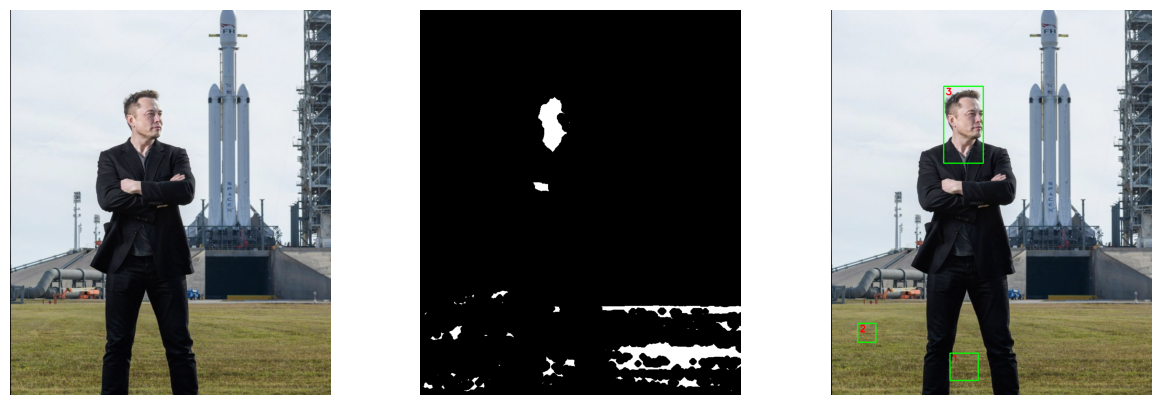

IDs:
1 2 3 4 5 6 


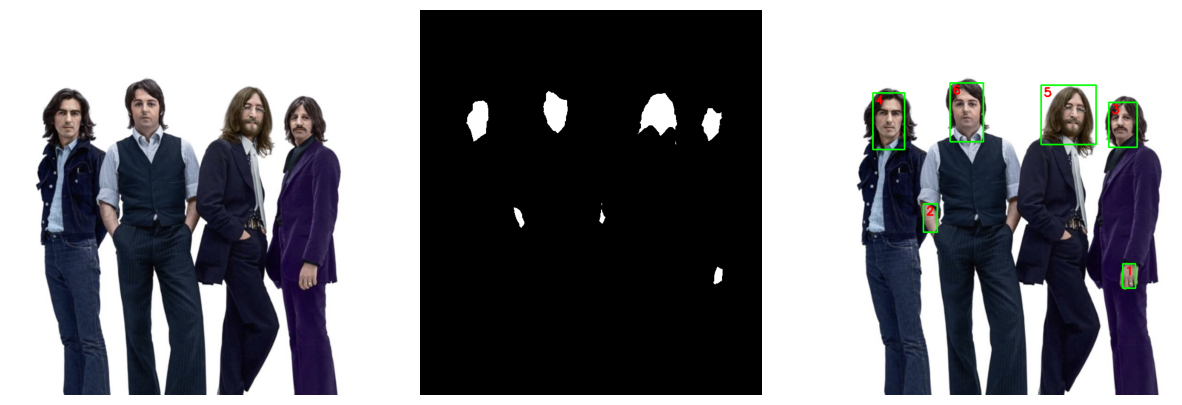

IDs:
1 2 3 4 


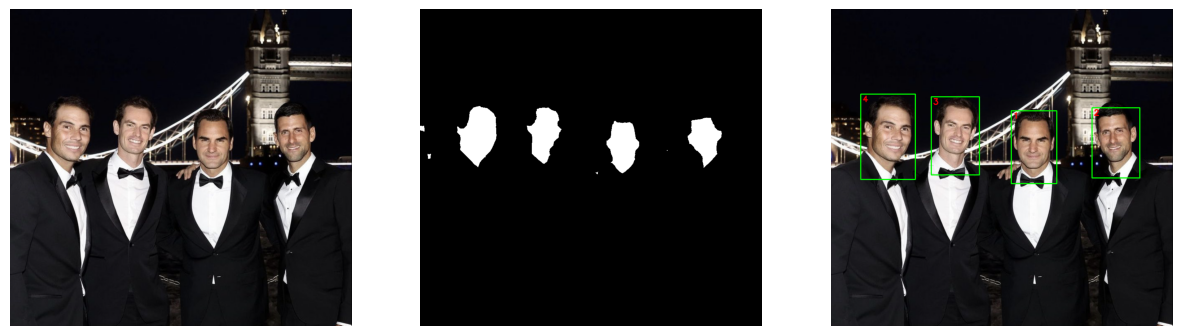

In [44]:
for i in range(1, 26):
    det = ProFaceDetector()
    det.process(f'multiple_face/im{i}.png', visualize=True, apply_blur=False)

IDs:
1 2 3 4 5 


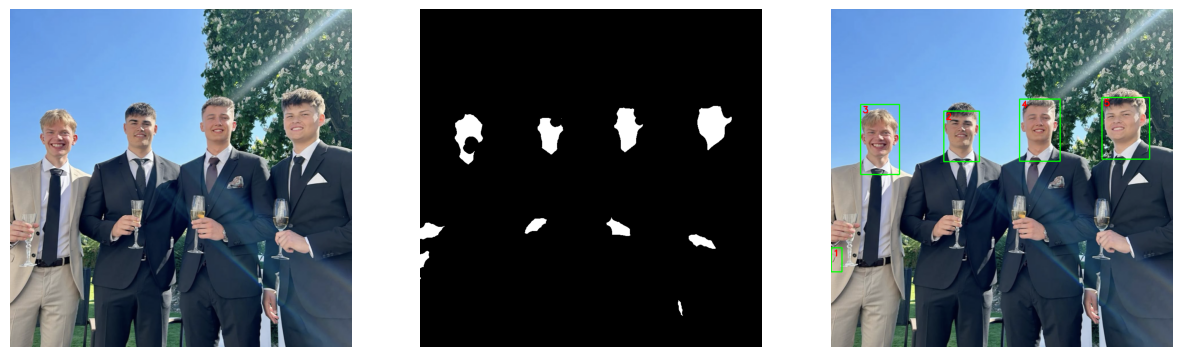

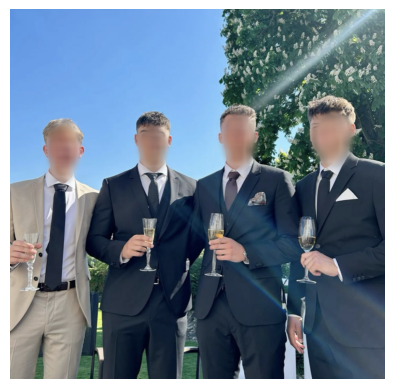

In [45]:
# Ejempo con apply_blur = True

det = ProFaceDetector()
det.process(f'multiple_face/im{5}.png', apply_blur=True)
print()

<h3 span style="color:orange; font-weight:bold;">3. Desenfoque en vídeo.</span></h3>

Vamos a usar el modo `apply_blur = True` para un vídeo. Haremos que cada frame sea blurreado y los uniremos para ver el resultado final. Si lo hubiésemos hecho selectivo como el primer modelo, tendríamos que haber seleccionado que cara desenfocar para cada uno de los frames, por lo que no sería posible.

En este caso, en la carpeta multiple_face se encuentra `video1.mp4` y `video2.mp4` para que corriendo el código se pueda comprobar su funcionamiento.

In [53]:
video_frames = cv2.VideoCapture('multiple_face/video2.mp4')
# video_frames = cv2.VideoCapture('multiple_face/video1.mp4')

fps = video_frames.get(cv2.CAP_PROP_FPS) 
if fps == 0: 
    fps = 30

delay_ms = int(1000 / fps)
print(f"FPS detectados: {fps}. Usando delay de: {delay_ms}ms")

# Tardará un poco antes de empezar el video dependiendo de lo grande que sea 
# (en el video 1 tarda uno 5 segundos y en el 2, 10 al ser más frames)
frames = []
print("Procesando video")

det = ProFaceDetector()

while True:
    ret, frame = video_frames.read()
    if not ret:
        break
    # Reutilizamos el detector ya creado si existe, para evitar recrearlo en cada frame
    blurred_frame, _ = det.process(frame, visualize=False, apply_blur=True)
    frames.append(blurred_frame)

print(f"Reproduciendo {len(frames)} frames")

cv2.namedWindow('Video con rostros difuminados', cv2.WINDOW_NORMAL)
cv2.startWindowThread()

for f in frames:
    cv2.imshow('Video con rostros difuminados', f)
    if cv2.waitKey(delay_ms) & 0xFF == ord('q'):
        # Si se presiona 'q' se cierra el video
        break
    
    try:
        if cv2.getWindowProperty('Video con rostros difuminados', cv2.WND_PROP_VISIBLE) < 1:
            break
    except:
        break

cv2.destroyAllWindows()

# Para evitar bugs de cierre de ventana
for i in range (5):
    cv2.waitKey(1)
    
# Si se queda pillado el IDE (OpenCV tiene problemas de compatibilidad con algunas versiones de MacOS),
# tocar una ventana de otra aplicación para liberar el hilo y volver a tocar la ventana del código.

FPS detectados: 60.0. Usando delay de: 16ms
Procesando video
Reproduciendo 811 frames


<h3 span style="color:orange; font-weight:bold;">3. Desenfoque en tiempo real.</span></h3>

Vamos a usar el modo `apply_blur = True` para desenfocar nuestra cara en tiempo real con la webcam. Haremos que cada frame sea blurreado en cada instante.

In [3]:
from IPython.display import clear_output
import cv2

def blur_faces_in_camera(verbose=False):
    
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error al abrir la cámara")
        return
    
    det = ProFaceDetector()

    while True:
        ret, frame = cap.read()
        if not ret:
            print("No se pudo capturar el frame")
            break
        
        frame = cv2.flip(frame, 1)
        img_blur, _ = det.process(frame, visualize=False, apply_blur=True) 
        
        if img_blur is None:
            print("No se pudo procesar el frame.")
            break      
        
        # Mostrar la imagen con blur
        cv2.imshow('Frame', img_blur)
        
        # Salir si se presiona la tecla 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
        # Salir si se cierra la ventana con la "X"
        try:
            if cv2.getWindowProperty('Frame', cv2.WND_PROP_VISIBLE) < 1:
                break
        except:
            break
    
    cap.release()
    cv2.destroyAllWindows()
    
    # Parche para macOS
    for i in range (5):
        cv2.waitKey(1)
        
# Si se queda pillado el IDE (OpenCV tiene problemas de compatibilidad con algunas versiones de MacOS),
# tocar una ventana de otra aplicación para liberar el hilo y volver a tocar la ventana del código.

In [4]:
blur_faces_in_camera()

Esta aproximación funciona incluso mejor que la anterior, aunque hemos creado la máscara de forma muy distinta y hemos sido mucho menos agresivos con las restricciones. Esto demuestra que no hay una forma perfecta y exacta de abordar el problema, sino que se puede tratar de buscar una solución desde muchos puntos de vista distintos, siempre y cuando prevalezca el rigor lógico y matemático de lo que estamos haciendo.

Al igual que con el primer modelo, hemos probado muchas otras combinaciones de hiperparámetros y no hemos encontrado un mejor funcionamiento. Consideramos que el trabajo invertido en desarrollar estas herramientas ha sido lo suficientemente complejo como para darnos cuenta de los puntos fuertes y las limitaciones de los fundamentos de análisis de imagen. Por ello, aunque hoy en dia el Deep Learning, las redes convolucionales, y otros algoritmos más complejos y con más facilidades puedan funcionar mejor, el punto de vista que te ofrece abordar los problemas desde esta perspectiva sigue pudiendo ser tremendamente útil, tanto para futuros desarrollos, como para entender realmente como funciona el nuevo paradigma. 